# 99_analyze — Black-Litterman 실험 결과 분석

각 섹션은 **하나의 질문**에 답합니다.

| 섹션 | 질문 |
|---|---|
| **A** | 전체 결과가 어떻게 됐나? |
| **B** | BL 자체가 의미있나? (vs naive_lowvol, CAPM) |
| **C** | P 슬롯: Trailing vol vs LSTM, 가중 방식 |
| **D** | Q 슬롯: fixed vs lambda vs inv_lambda vs raw_lam vs ff3_paper |
| **E** | 최적 조합 상세 분석 |
| **F** | Trailing vs LSTM — 왜 성과 차이가 나는가? |
| **G** | Omega 슬롯: he_litterman vs 논문 방식 (ff3_paper) |

In [45]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '99_analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['baseline']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["baseline"]["ret"].index[0].date()} ~ {loaded["baseline"]["ret"].index[-1].date()}')

로드 완료: 26개 실험
기간: 2010-01-31 ~ 2024-12-31


## A. 전체 결과 요약

> **19개 실험 한눈에 — Sharpe 기준 정렬**

In [46]:
# ── A1. 성과 테이블 ────────────────────────────────────────────
rows = []
for name in sorted(loaded.keys()):
    m = calc(name)
    rows.append(dict(
        실험명   = name,
        Sharpe   = round(m['sharpe'],  3),
        CAGR     = f"{m['cagr']*100:.1f}%",
        Vol      = f"{m['vol']*100:.1f}%",
        MDD      = f"{m['mdd']*100:.1f}%",
        Sortino  = round(m['sortino'], 3),
        누적수익 = f"{m['total']*100:.0f}%",
    ))

# SPY 추가
ms = calc_spy()
rows.append(dict(
    실험명='SPY', Sharpe=round(ms['sharpe'],3),
    CAGR=f"{ms['cagr']*100:.1f}%", Vol=f"{ms['vol']*100:.1f}%",
    MDD=f"{ms['mdd']*100:.1f}%", Sortino='-', 누적수익=f"{ms['total']*100:.0f}%"
))

df_tbl = pd.DataFrame(rows).set_index('실험명').sort_values('Sharpe', ascending=False)

def hl_sharpe(v):
    try:
        v = float(v)
        if v >= 1.15: return 'background-color:#c6efce;color:#276221;font-weight:bold'
        if v >= 1.05: return 'background-color:#ffeb9c;color:#9c5700'
        if v >= 0.95: return ''
        return 'background-color:#ffc7ce;color:#9c0006'
    except: return ''

display(df_tbl.style.applymap(hl_sharpe, subset=['Sharpe']))

,Sharpe,CAGR,Vol,MDD,Sortino,누적수익
실험명,,,,,,
omega_paper,1.122000,15.9%,13.1%,-15.7%,1.651000,839%
baseline,1.111000,13.4%,11.0%,-13.0%,1.762000,572%
prior_eq,1.111000,14.2%,11.7%,-13.9%,1.695000,653%
q_raw_lam,1.081000,13.3%,11.2%,-12.7%,1.978000,559%
q_inv_lambda,1.080000,13.5%,11.4%,-13.9%,1.529000,580%
q_lambda,1.072000,13.0%,11.0%,-12.7%,1.917000,534%
p_lstm_eq,1.068000,13.0%,11.0%,-12.6%,1.632000,531%
naive_lowvol,1.065000,13.9%,11.9%,-14.7%,1.569000,612%
p_rp,1.057000,12.8%,11.0%,-12.9%,1.658000,520%


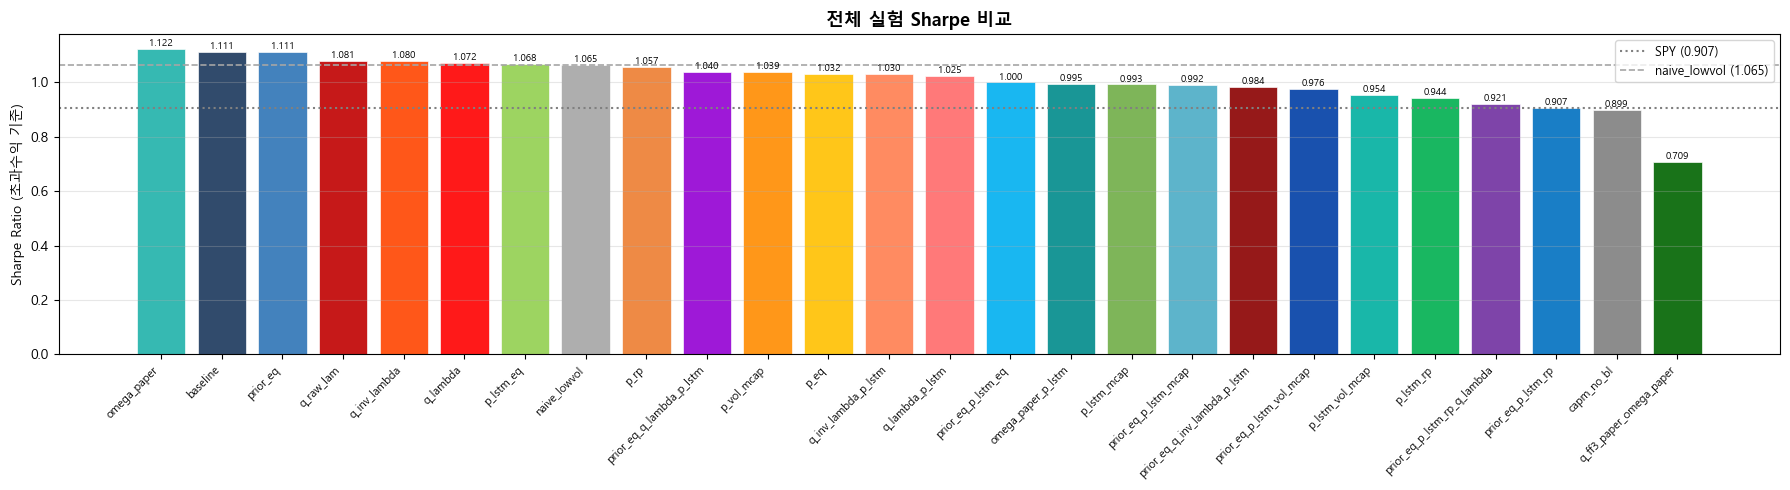

In [47]:
# ── A2. Sharpe 막대 차트 ───────────────────────────────────────
# 그룹별 색상
GROUP_COLOR = {
    # baseline / prior
    'baseline'                      : '#1A375C',
    'prior_eq'                      : '#2E75B6',
    # P 가중 방식 (Trailing)
    'p_rp'                          : '#ED7D31',
    'p_eq'                          : '#FFC000',
    'p_vol_mcap'                    : '#FF8C00',
    # P = LSTM (mcap prior)
    'p_lstm_mcap'                   : '#70AD47',
    'p_lstm_eq'                     : '#92D050',
    'p_lstm_rp'                     : '#00B050',
    'p_lstm_vol_mcap'               : '#00B0A0',
    # P = LSTM (eq prior)
    'prior_eq_p_lstm_mcap'          : '#4BACC6',
    'prior_eq_p_lstm_eq'            : '#00B0F0',
    'prior_eq_p_lstm_rp'            : '#0070C0',
    'prior_eq_p_lstm_vol_mcap'      : '#003EA5',
    # Q = lambda (정방향: 강세↑Q)
    'q_lambda'                      : '#FF0000',
    'q_raw_lam'                     : '#C00000',
    'q_lambda_p_lstm'               : '#FF6B6B',
    # Q = inv_lambda (역방향: 위기↑Q)
    'q_inv_lambda'                  : '#FF4500',
    'q_inv_lambda_p_lstm'           : '#FF7F50',
    # 최적 조합
    'prior_eq_p_lstm_rp_q_lambda'   : '#7030A0',
    'prior_eq_q_inv_lambda_p_lstm'  : '#8B0000',
    'prior_eq_q_lambda_p_lstm'      : '#9400D3',
    # Omega / FF3 논문 방식
    'q_ff3_paper'                   : '#228B22',
    'q_ff3_paper_omega_paper'       : '#006400',
    'omega_paper'                   : '#20B2AA',
    'omega_paper_p_lstm'            : '#008B8B',
    # 비교군
    'capm_no_bl'                    : '#808080',
    'naive_lowvol'                  : '#A5A5A5',
}

order = df_tbl.index.tolist()
names_plot = [n for n in order if n != 'SPY']
sharpes    = [calc(n)['sharpe'] for n in names_plot]
colors     = [GROUP_COLOR.get(n, '#BDBDBD') for n in names_plot]

fig, ax = plt.subplots(figsize=(18, 5))
bars = ax.bar(range(len(names_plot)), sharpes, color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)
ax.axhline(calc_spy()['sharpe'], color='gray', linestyle=':', linewidth=1.5, label=f"SPY ({calc_spy()['sharpe']:.3f})")
ax.axhline(calc('naive_lowvol')['sharpe'], color='#A5A5A5', linestyle='--', linewidth=1.2,
           label=f"naive_lowvol ({calc('naive_lowvol')['sharpe']:.3f})")

for bar, v in zip(bars, sharpes):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}',
            ha='center', va='bottom', fontsize=7)

ax.set_xticks(range(len(names_plot)))
ax.set_xticklabels(names_plot, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sharpe Ratio (초과수익 기준)')
ax.set_title('전체 실험 Sharpe 비교', fontweight='bold', fontsize=13)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'A_sharpe_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## B. BL이 의미있나?

> `naive_lowvol` (BL 없이 저변동 직접 보유) / `capm_no_bl` (CAPM 직접 최적화) / `baseline` (BL 적용)

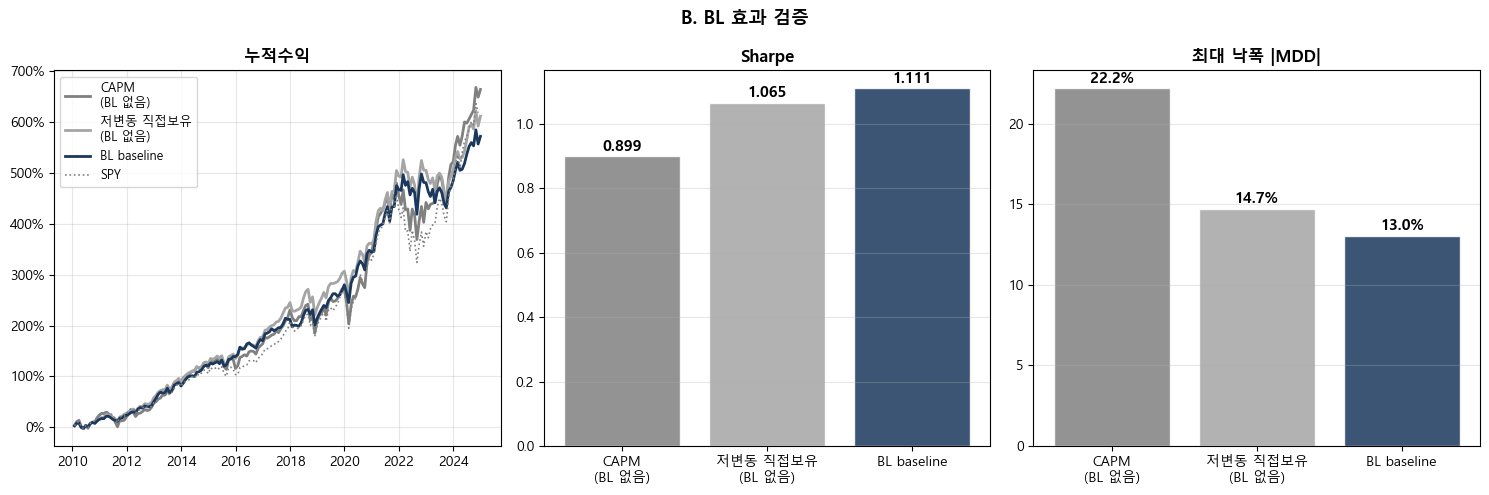

BL 추가 효과 (baseline vs naive_lowvol):
  Sharpe  : 1.065 → 1.111  (+0.046)
  MDD     : -14.7% → -13.0%  (+1.7%p)


In [48]:
bl_compare = ['capm_no_bl', 'naive_lowvol', 'baseline']
bl_labels  = ['CAPM\n(BL 없음)', '저변동 직접보유\n(BL 없음)', 'BL baseline']
bl_colors  = ['#808080', '#A5A5A5', '#1A375C']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 누적수익
ax = axes[0]
for name, label, c in zip(bl_compare, bl_labels, bl_colors):
    m = calc(name)
    ax.plot(m['cum'].index, m['cum'].values - 1, label=label, linewidth=2.0, color=c)
ax.plot(ms['cum'].index, ms['cum'].values - 1, label='SPY', linewidth=1.2,
        linestyle=':', color='gray')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('누적수익', fontweight='bold'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Sharpe 막대
ax = axes[1]
vals = [calc(n)['sharpe'] for n in bl_compare]
bars = ax.bar(bl_labels, vals, color=bl_colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Sharpe', fontweight='bold'); ax.grid(alpha=0.3, axis='y')

# MDD 막대 (절댓값)
ax = axes[2]
vals_mdd = [abs(calc(n)['mdd'])*100 for n in bl_compare]
bars = ax.bar(bl_labels, vals_mdd, color=bl_colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, vals_mdd):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('최대 낙폭 |MDD|', fontweight='bold'); ax.grid(alpha=0.3, axis='y')

plt.suptitle('B. BL 효과 검증', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'B_bl_effect.png', dpi=150, bbox_inches='tight')
plt.show()

m_b = calc('baseline'); m_n = calc('naive_lowvol')
print(f'BL 추가 효과 (baseline vs naive_lowvol):')
print(f'  Sharpe  : {m_n["sharpe"]:.3f} → {m_b["sharpe"]:.3f}  ({m_b["sharpe"]-m_n["sharpe"]:+.3f})')
print(f'  MDD     : {m_n["mdd"]*100:.1f}% → {m_b["mdd"]*100:.1f}%  ({(m_b["mdd"]-m_n["mdd"])*100:+.1f}%p)')

## C. P 슬롯 — Trailing vol vs LSTM

> 같은 가중 방식 안에서 변동성 측정 방법(trailing vs LSTM)의 차이

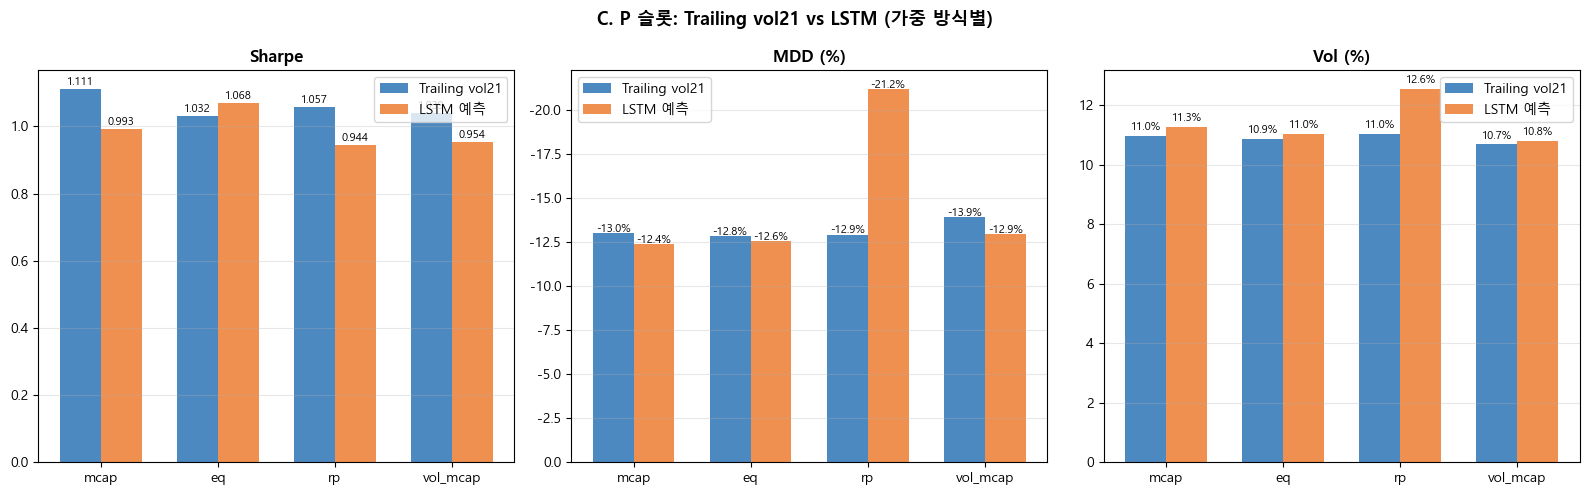

LSTM 효과 (Sharpe 차이, LSTM - Trailing):
  mcap      : -0.118
  eq        : +0.036
  rp        : -0.113
  vol_mcap  : -0.085


In [49]:
weights      = ['mcap', 'eq', 'rp', 'vol_mcap']
trailing_exp = ['baseline', 'p_eq', 'p_rp', 'p_vol_mcap']
lstm_exp     = ['p_lstm_mcap', 'p_lstm_eq', 'p_lstm_rp', 'p_lstm_vol_mcap']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(weights)); bw = 0.35

for ax, key, title, pct in zip(
    axes,
    ['sharpe', 'mdd', 'vol'],
    ['Sharpe', 'MDD (%)', 'Vol (%)'    ],
    [False,     True,      True        ]
):
    t_vals = [calc(n)[key] * (100 if pct else 1) for n in trailing_exp]
    l_vals = [calc(n)[key] * (100 if pct else 1) for n in lstm_exp]

    b1 = ax.bar(x - bw/2, t_vals, bw, label='Trailing vol21', color='#2E75B6', alpha=0.85)
    b2 = ax.bar(x + bw/2, l_vals, bw, label='LSTM 예측',      color='#ED7D31', alpha=0.85)

    fmt = '{:.1f}%' if pct else '{:.3f}'
    for bars, vals in [(b1, t_vals), (b2, l_vals)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height() + (0.003 if not pct else 0.1),
                    fmt.format(v), ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(weights, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    if key == 'mdd': ax.invert_yaxis()

plt.suptitle('C. P 슬롯: Trailing vol21 vs LSTM (가중 방식별)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'C_trailing_vs_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

print('LSTM 효과 (Sharpe 차이, LSTM - Trailing):')
for w, t, l in zip(weights, trailing_exp, lstm_exp):
    d = calc(l)['sharpe'] - calc(t)['sharpe']
    print(f'  {w:10s}: {d:+.3f}')

## D. Q 슬롯 — fixed vs lambda vs inv_lambda vs raw_lam vs ff3_paper

> Q 조절 방식이 성과에 어떤 영향을 주는가?
> - **fixed**: Q=0.003 고정
> - **lambda**: 강세장 λ↑ → Q↑ (시장 안정 시 뷰 강화)
> - **inv_lambda**: 위기장 λ↓ → Q↑ (위기 시 뷰 강화)
> - **raw_lam**: λ 부호 기반 게이팅 (SPY 하락 시 Q→0)
> - **ff3_paper**: 전월 실현 FF3 팩터로 Q 계산

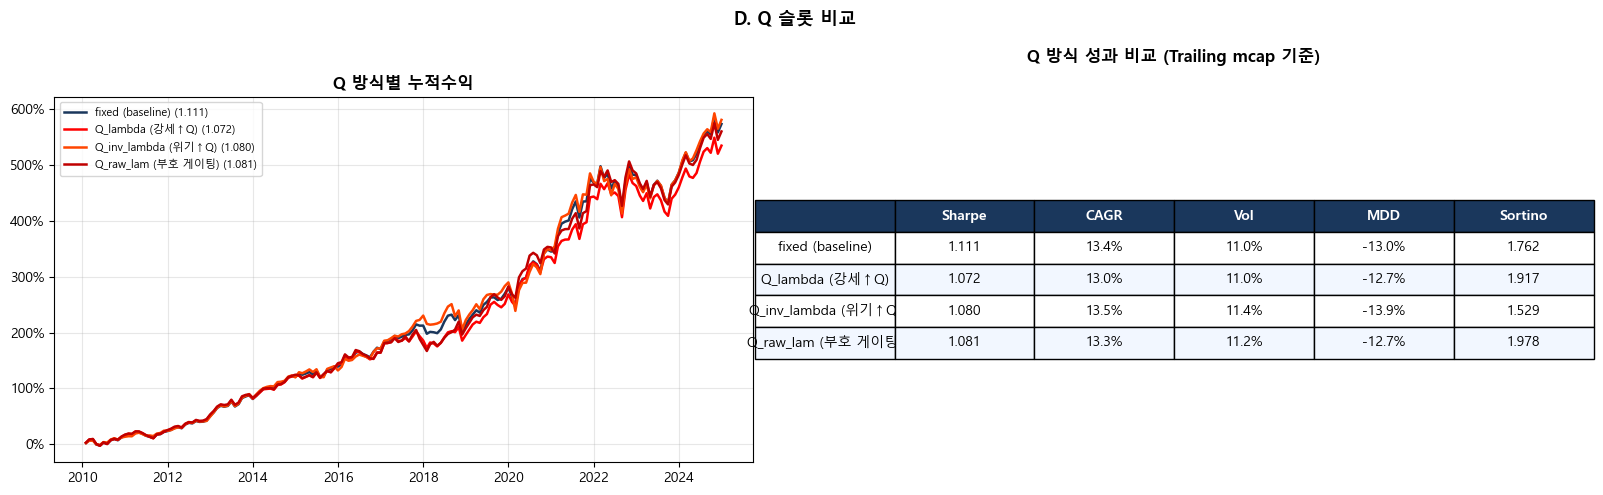

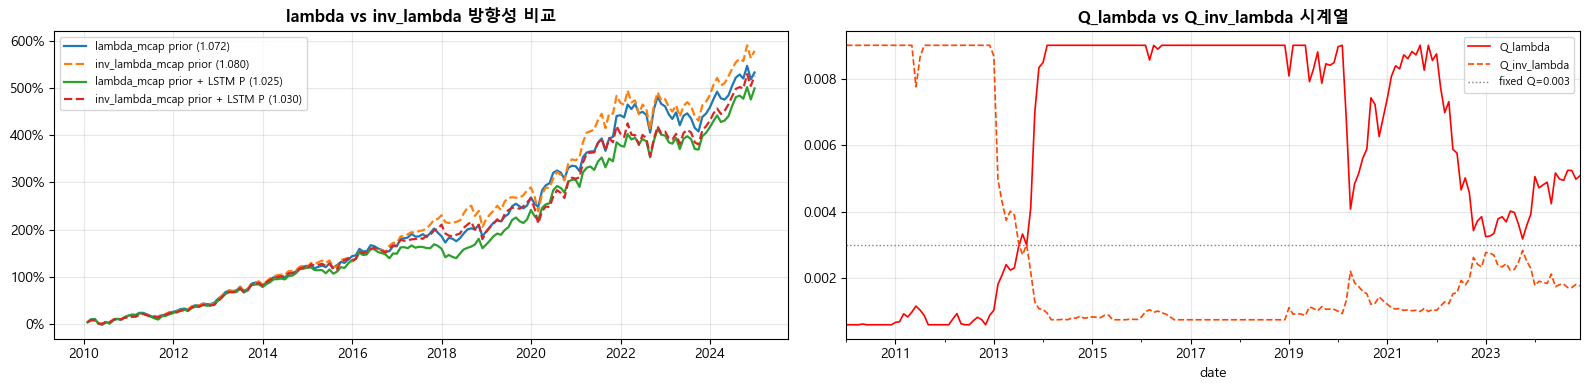

In [50]:
# ── D1. Q 방식 전체 비교 (Trailing P mcap 기준) ────────────────
q_exps   = ['baseline', 'q_lambda', 'q_inv_lambda', 'q_raw_lam', 'q_ff3_paper']
q_labels = ['fixed\n(baseline)', 'Q_lambda\n(강세↑Q)', 'Q_inv_lambda\n(위기↑Q)', 'Q_raw_lam\n(부호 게이팅)', 'Q_ff3_paper\n(FF3 실현)']
colors_q = ['#1A375C', '#FF0000', '#FF4500', '#C00000', '#228B22']

# 존재하는 실험만 필터
q_avail   = [(n, l, c) for n, l, c in zip(q_exps, q_labels, colors_q) if n in loaded]
q_exps    = [x[0] for x in q_avail]
q_labels  = [x[1] for x in q_avail]
colors_q  = [x[2] for x in q_avail]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 누적수익
ax = axes[0]
for name, label, c in zip(q_exps, q_labels, colors_q):
    m = calc(name)
    ax.plot(m['cum'].index, m['cum'].values - 1,
            label=f"{label.replace(chr(10),' ')} ({m['sharpe']:.3f})",
            linewidth=1.8, color=c)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Q 방식별 누적수익', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 성과 테이블
ax = axes[1]
ax.axis('off')
tdata = [['', 'Sharpe', 'CAGR', 'Vol', 'MDD', 'Sortino']]
for name, label, c in zip(q_exps, q_labels, colors_q):
    m = calc(name)
    tdata.append([label.replace('\n', ' '),
                  f"{m['sharpe']:.3f}",
                  f"{m['cagr']*100:.1f}%",
                  f"{m['vol']*100:.1f}%",
                  f"{m['mdd']*100:.1f}%",
                  f"{m['sortino']:.3f}"])

tbl = ax.table(cellText=tdata[1:], colLabels=tdata[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1A375C'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F2F7FF')
ax.set_title('Q 방식 성과 비교 (Trailing mcap 기준)', fontweight='bold', pad=25)

plt.suptitle('D. Q 슬롯 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'D_q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── D2. lambda vs inv_lambda 방향성 비교 ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
lambda_pairs = [
    ('q_lambda',     'q_inv_lambda',     'mcap prior'),
    ('q_lambda_p_lstm', 'q_inv_lambda_p_lstm', 'mcap prior + LSTM P'),
]
for base_n, inv_n, lbl in lambda_pairs:
    if base_n in loaded and inv_n in loaded:
        mb = calc(base_n); mi = calc(inv_n)
        ax.plot(mb['cum'].index, mb['cum'].values - 1,
                label=f"lambda_{lbl} ({mb['sharpe']:.3f})", linewidth=1.6)
        ax.plot(mi['cum'].index, mi['cum'].values - 1,
                label=f"inv_lambda_{lbl} ({mi['sharpe']:.3f})", linewidth=1.6, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('lambda vs inv_lambda 방향성 비교', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Q_lambda 시계열
ax = axes[1]
if 'q_lambda' in loaded and 'meta' in loaded['q_lambda']:
    meta = loaded['q_lambda']['meta']
    if 'Q' in meta.columns:
        meta['Q'].plot(ax=ax, color='#FF0000', linewidth=1.2, label='Q_lambda')
if 'q_inv_lambda' in loaded and 'meta' in loaded['q_inv_lambda']:
    meta_inv = loaded['q_inv_lambda']['meta']
    if 'Q' in meta_inv.columns:
        meta_inv['Q'].plot(ax=ax, color='#FF4500', linewidth=1.2, linestyle='--', label='Q_inv_lambda')
ax.axhline(0.003, color='gray', linestyle=':', linewidth=1, label='fixed Q=0.003')
ax.set_title('Q_lambda vs Q_inv_lambda 시계열', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'D_lambda_vs_invlambda.png', dpi=150, bbox_inches='tight')
plt.show()

## E. 최적 조합 — 상위 실험 상세 분석

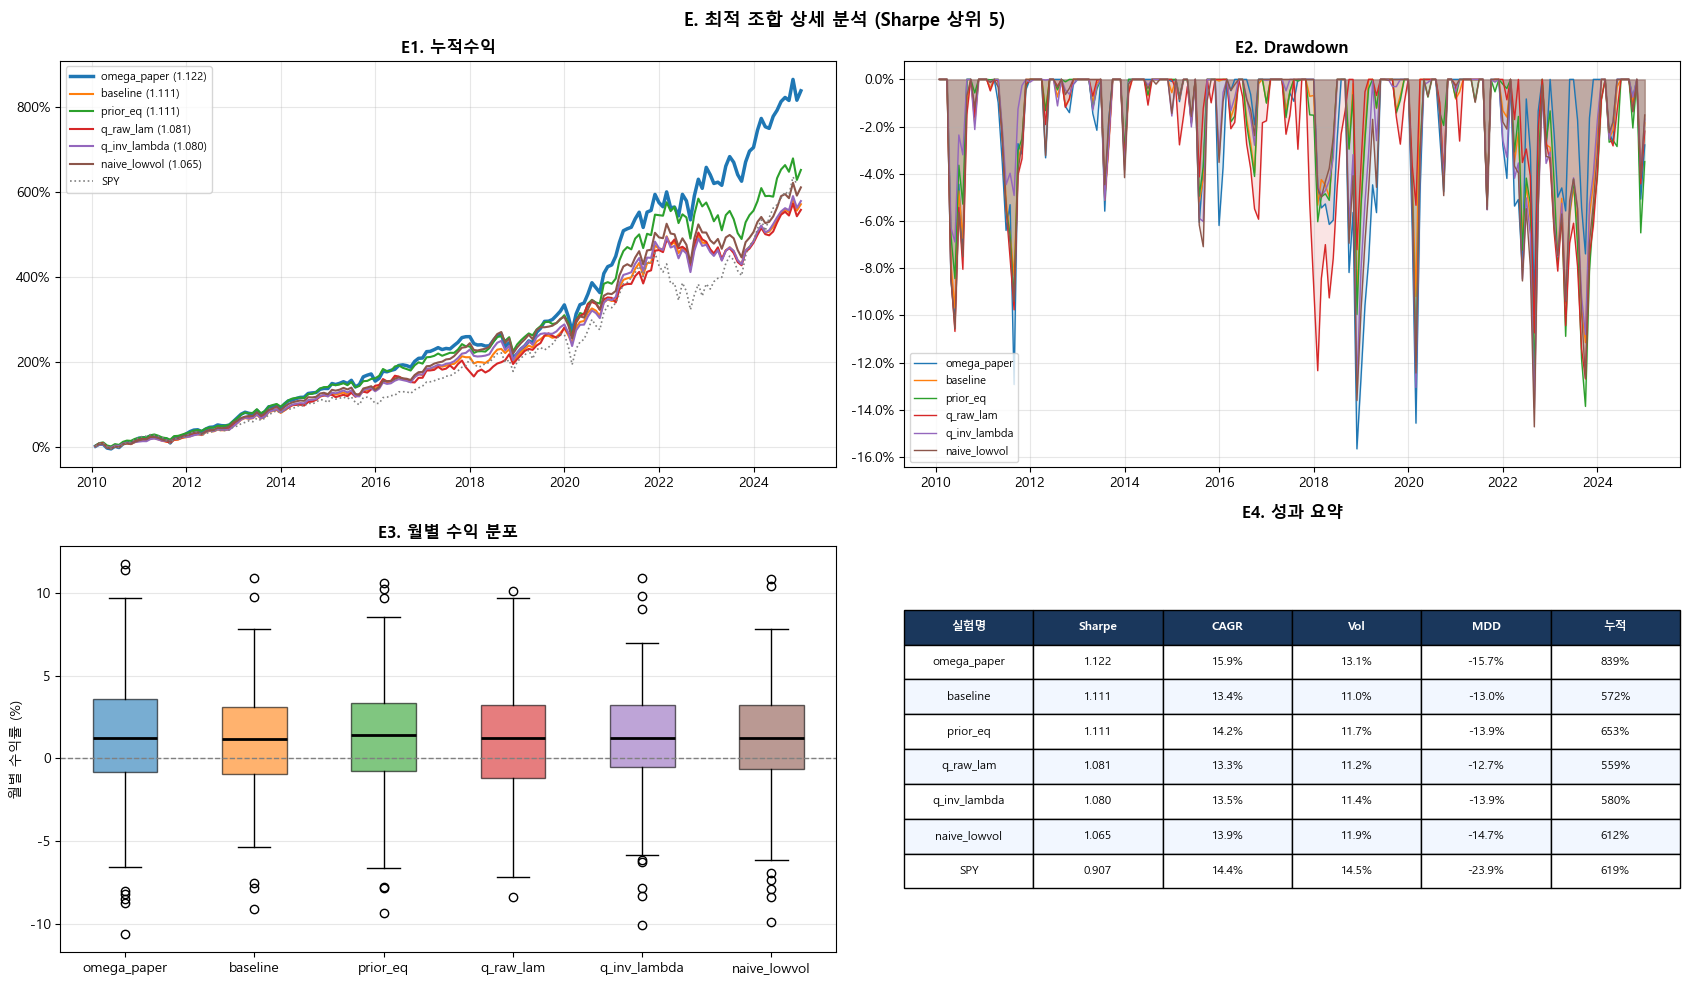


=== 최종 순위 (Sharpe 기준) ===
   1. omega_paper                                    Sharpe 1.122  MDD -15.7%  누적 839%
   2. baseline                                       Sharpe 1.111  MDD -13.0%  누적 572%
   3. prior_eq                                       Sharpe 1.111  MDD -13.9%  누적 653%
   4. q_raw_lam                                      Sharpe 1.081  MDD -12.7%  누적 559%
   5. q_inv_lambda                                   Sharpe 1.080  MDD -13.9%  누적 580%
   6. q_lambda                                       Sharpe 1.072  MDD -12.7%  누적 534%
   7. p_lstm_eq                                      Sharpe 1.068  MDD -12.6%  누적 531%
   8. naive_lowvol                                   Sharpe 1.065  MDD -14.7%  누적 612%
   9. p_rp                                           Sharpe 1.057  MDD -12.9%  누적 520%
  10. prior_eq_q_lambda_p_lstm                       Sharpe 1.040  MDD -12.0%  누적 564%


In [51]:
# Sharpe 상위 5개 선정
rank = sorted(loaded.keys(), key=lambda n: -calc(n)['sharpe'])
top5 = rank[:5]
show = top5 + (['naive_lowvol'] if 'naive_lowvol' not in top5 else [])

colors_e = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(17, 10))

# E1. 누적수익
ax = axes[0, 0]
for i, name in enumerate(show):
    m = calc(name)
    lw = 2.5 if i == 0 else 1.5
    ax.plot(m['cum'].index, m['cum'].values - 1,
            label=f"{name} ({m['sharpe']:.3f})",
            linewidth=lw, color=colors_e[i])
ax.plot(ms['cum'].index, ms['cum'].values - 1,
        label='SPY', linewidth=1.2, linestyle=':', color='gray')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('E1. 누적수익', fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# E2. Drawdown
ax = axes[0, 1]
for i, name in enumerate(show):
    m  = calc(name)
    dd = (m['cum'] / m['cum'].cummax()) - 1
    ax.fill_between(dd.index, dd.values, 0, alpha=0.12, color=colors_e[i])
    ax.plot(dd.index, dd.values, linewidth=1.0, color=colors_e[i], label=name)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('E2. Drawdown', fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# E3. 월별 수익 분포 (박스플롯)
ax = axes[1, 0]
data   = [calc(n)['ret'].values * 100 for n in show]
bp     = ax.boxplot(data, labels=[n.replace('_prior_eq','\nprior_eq') for n in show],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors_e):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('월별 수익률 (%)'); ax.set_title('E3. 월별 수익 분포', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# E4. 성과 요약 테이블
ax = axes[1, 1]
ax.axis('off')
hdr  = ['실험명', 'Sharpe', 'CAGR', 'Vol', 'MDD', '누적']
body = []
for name in show + ['SPY']:
    m = calc(name) if name != 'SPY' else calc_spy()
    body.append([name,
                 f"{m['sharpe']:.3f}",
                 f"{m['cagr']*100:.1f}%",
                 f"{m['vol']*100:.1f}%",
                 f"{m['mdd']*100:.1f}%",
                 f"{m['total']*100:.0f}%"])
tbl = ax.table(cellText=body, colLabels=hdr, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1A375C'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F2F7FF')
ax.set_title('E4. 성과 요약', fontweight='bold', pad=20)

plt.suptitle('E. 최적 조합 상세 분석 (Sharpe 상위 5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'E_best_combo.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== 최종 순위 (Sharpe 기준) ===')
for i, name in enumerate(rank[:10], 1):
    m = calc(name)
    print(f'  {i:2d}. {name:45s}  Sharpe {m["sharpe"]:.3f}  MDD {m["mdd"]*100:.1f}%  누적 {m["total"]*100:.0f}%')

## F. Trailing vs LSTM — 왜 성과 차이가 나는가?

> 종목 구성과 섹터 비중으로 전략 차이를 확인합니다.

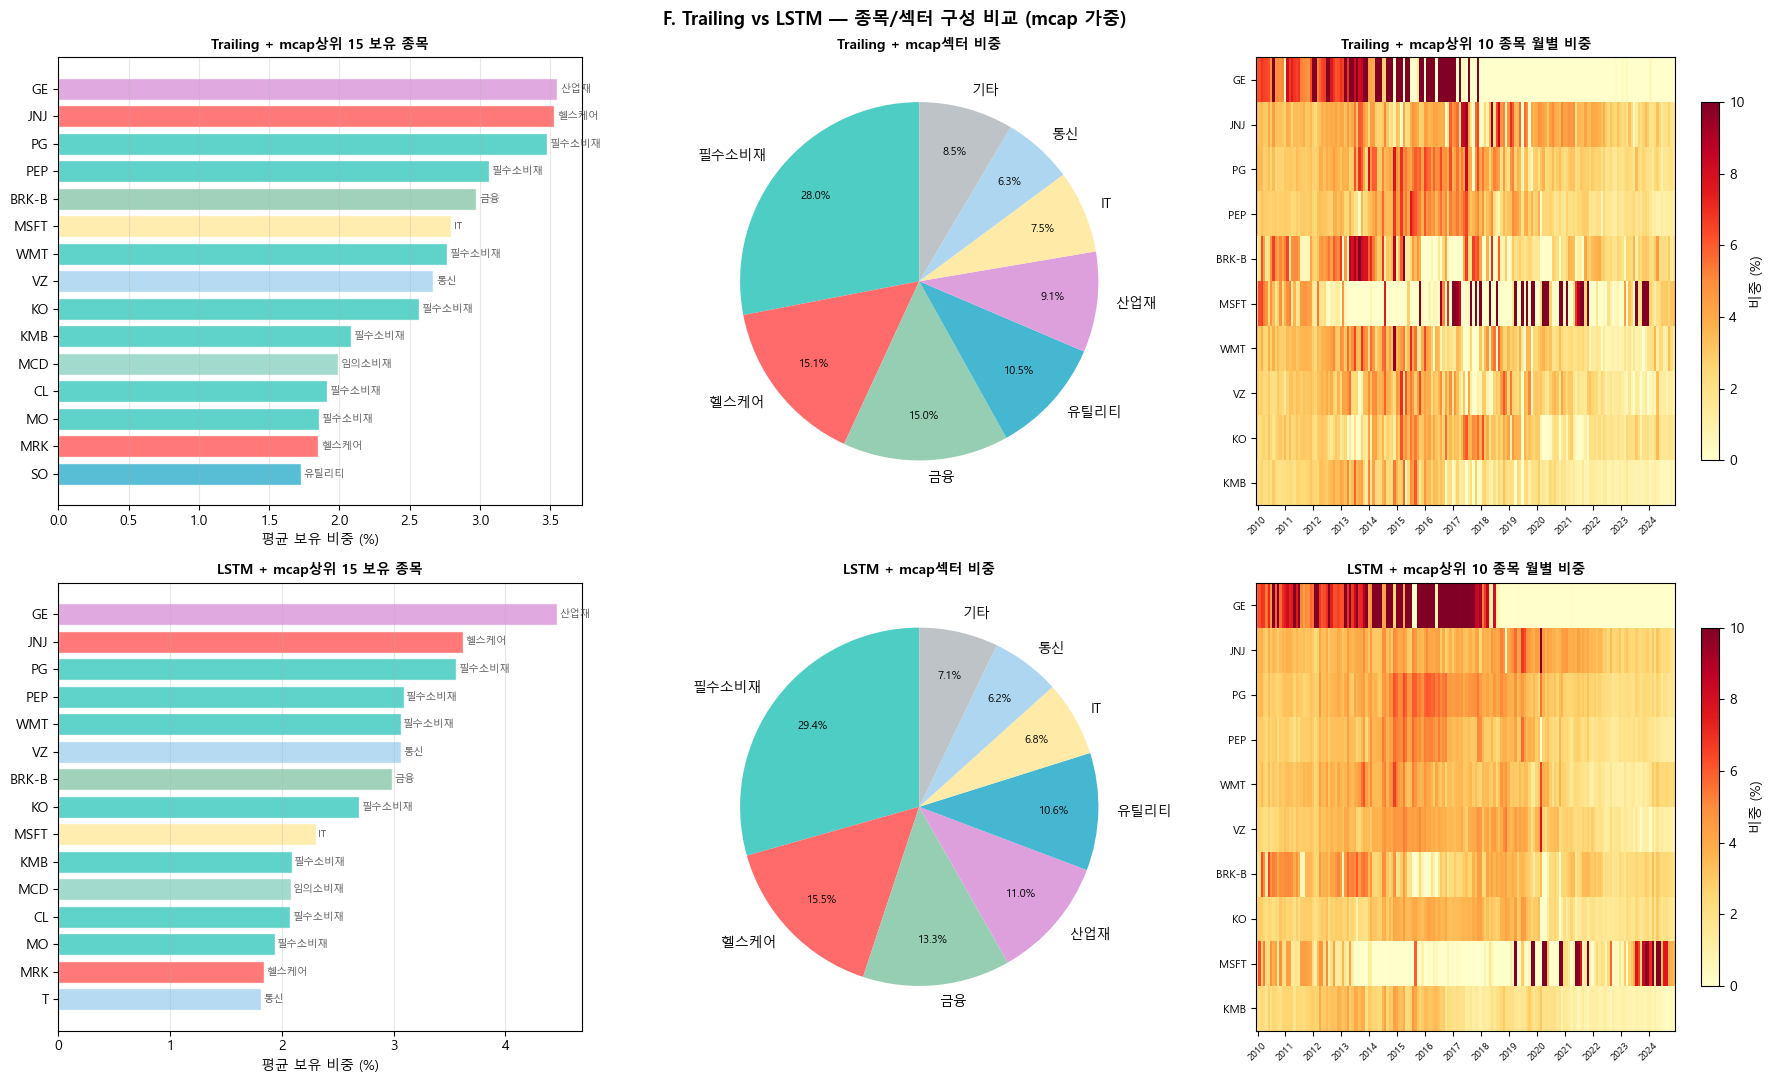

=== 섹터 비중 비교 ===
섹터              Trailing        LSTM        차이
---------------------------------------------
필수소비재              28.0%       29.4%     +1.4%
헬스케어               15.1%       15.5%     +0.4%
금융                 15.0%       13.3%     -1.7%
유틸리티               10.5%       10.6%     +0.1%
산업재                 9.1%       11.0%     +1.9%
IT                  7.5%        6.8%     -0.7%
통신                  6.3%        6.2%     -0.1%
임의소비재               3.9%        3.5%     -0.4%
부동산                 2.2%        1.8%     -0.4%
에너지                 1.7%        1.3%     -0.4%
소재                  0.5%        0.4%     -0.1%
기타                  0.2%        0.1%     -0.1%


In [52]:
# ── 섹터 데이터 로드 & 정규화 ──────────────────────────────
panel_sector = pd.read_csv(
    Path.cwd() / "data" / "monthly_panel.csv",
    usecols=["date","ticker","gics_sector"], parse_dates=["date"]
)

SECTOR_MAP = {
    "Information Technology": "IT",         "Technology"            : "IT",
    "Health Care"           : "헬스케어",    "Healthcare"            : "헬스케어",
    "Consumer Staples"      : "필수소비재",  "Consumer Defensive"    : "필수소비재",
    "Utilities"             : "유틸리티",
    "Financials"            : "금융",        "Financial Services"    : "금융",
    "Industrials"           : "산업재",
    "Consumer Discretionary": "임의소비재",  "Consumer Cyclical"     : "임의소비재",
    "Energy"                : "에너지",
    "Communication Services": "통신",
    "Materials"             : "소재",        "Basic Materials"       : "소재",
    "Real Estate"           : "부동산",
}
panel_sector["sector"] = panel_sector["gics_sector"].map(lambda x: SECTOR_MAP.get(x, "기타"))
ticker_sector = panel_sector.groupby("ticker")["sector"].agg(lambda x: x.mode().iloc[0])

# ── 비교 두 전략 ─────────────────────────────────────────────
compare_pair = [("baseline", "Trailing + mcap"), ("p_lstm_mcap", "LSTM + mcap")]

SCOL = {
    "헬스케어":"#FF6B6B", "필수소비재":"#4ECDC4", "유틸리티":"#45B7D1",
    "금융":"#96CEB4",     "IT":"#FFEAA7",         "산업재":"#DDA0DD",
    "임의소비재":"#98D8C8","에너지":"#F7DC6F",     "기타":"#BDC3C7",
    "통신":"#AED6F1",     "소재":"#FAD7A0",        "부동산":"#A9CCE3",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for row_idx, (name, label) in enumerate(compare_pair):
    w_df = loaded[name]["weights"]

    # F1. 상위 15 보유 종목
    ax = axes[row_idx, 0]
    avg_w = w_df.mean().sort_values(ascending=False).head(15)
    secs  = [ticker_sector.get(t, "기타") for t in avg_w.index]
    bars  = ax.barh(avg_w.index[::-1], avg_w.values[::-1]*100,
                    color=[SCOL.get(s,"#BDC3C7") for s in secs[::-1]],
                    alpha=0.9, edgecolor="white")
    for bar, s in zip(bars, secs[::-1]):
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                s, va="center", fontsize=7.5, color="#555")
    ax.set_xlabel("평균 보유 비중 (%)")
    ax.set_title(f"{label}상위 15 보유 종목", fontweight="bold", fontsize=10)
    ax.grid(alpha=0.3, axis="x")

    # F2. 섹터 비중 파이차트
    ax = axes[row_idx, 1]
    sw = {}
    for ticker in w_df.columns:
        sec = ticker_sector.get(ticker, "기타")
        sw[sec] = sw.get(sec, 0) + w_df[ticker].mean()
    sw_s  = pd.Series(sw).sort_values(ascending=False)
    total = sw_s.sum()
    major = sw_s[sw_s/total >= 0.04].copy()
    other = sw_s[sw_s/total < 0.04].sum()
    if other > 0:
        major["기타"] = major.get("기타", 0) + other
    _, texts, autotexts = ax.pie(
        major.values, labels=major.index,
        autopct="%1.1f%%", colors=[SCOL.get(s,"#BDC3C7") for s in major.index],
        startangle=90, pctdistance=0.75
    )
    for t in autotexts: t.set_fontsize(8)
    ax.set_title(f"{label}섹터 비중", fontweight="bold", fontsize=10)

    # F3. 상위 10 종목 월별 비중 히트맵
    ax = axes[row_idx, 2]
    top10     = w_df.mean().sort_values(ascending=False).head(10).index
    heat_data = w_df[top10].T * 100
    im = ax.imshow(heat_data.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
    ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10, fontsize=8)
    years    = [d.year for d in heat_data.columns]
    yr_ticks = [i for i in range(len(years)) if i == 0 or years[i] != years[i-1]]
    ax.set_xticks(yr_ticks)
    ax.set_xticklabels([years[i] for i in yr_ticks], rotation=45, fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label="비중 (%)")
    ax.set_title(f"{label}상위 10 종목 월별 비중", fontweight="bold", fontsize=10)

plt.suptitle("F. Trailing vs LSTM — 종목/섹터 구성 비교 (mcap 가중)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "F_holdings_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 섹터 비중 텍스트 요약 ────────────────────────────────────
def get_sector_w(name):
    w_df = loaded[name]["weights"]
    sw = {}
    for ticker in w_df.columns:
        sec = ticker_sector.get(ticker, "기타")
        sw[sec] = sw.get(sec, 0) + w_df[ticker].mean()
    total = sum(sw.values())
    return pd.Series({k: v/total for k, v in sw.items()})

sw_trail = get_sector_w("baseline")
sw_lstm  = get_sector_w("p_lstm_mcap")
all_secs = sorted(set(sw_trail.index)|set(sw_lstm.index), key=lambda s: -sw_trail.get(s,0))

print("=== 섹터 비중 비교 ===")
print(f"{'섹터':12s}  {'Trailing':>10s}  {'LSTM':>10s}  {'차이':>8s}")
print("-"*45)
for sec in all_secs:
    t = sw_trail.get(sec, 0); l = sw_lstm.get(sec, 0)
    print(f"{sec:12s}  {t:>10.1%}  {l:>10.1%}  {l-t:>+8.1%}")


## G. Omega 슬롯 — he_litterman vs 논문 방식 (ff3_paper)

> Ω 계산 방식이 성과에 어떤 영향을 주는가?
> - **he_litterman** (기본): Ω = τ·P·Σ·Pᵀ
> - **ff3_paper** (논문): Ω_t = (Q_hat_{t-1} − Q_actual_{t-1})²  (전월 예측오차²)
>
> | 실험명 | Q 방식 | Ω 방식 | 설명 |
> |---|---|---|---|
> | `baseline` | fixed | he_litterman | 기준 |
> | `omega_paper` | fixed | ff3_paper | Ω만 논문 방식 |
> | `omega_paper_p_lstm` | fixed | ff3_paper | Ω 논문 + LSTM P |
> | `q_ff3_paper` | ff3_paper | he_litterman | Q만 논문 방식 |
> | `q_ff3_paper_omega_paper` | ff3_paper | ff3_paper | Q+Ω 완전 논문 구현 |

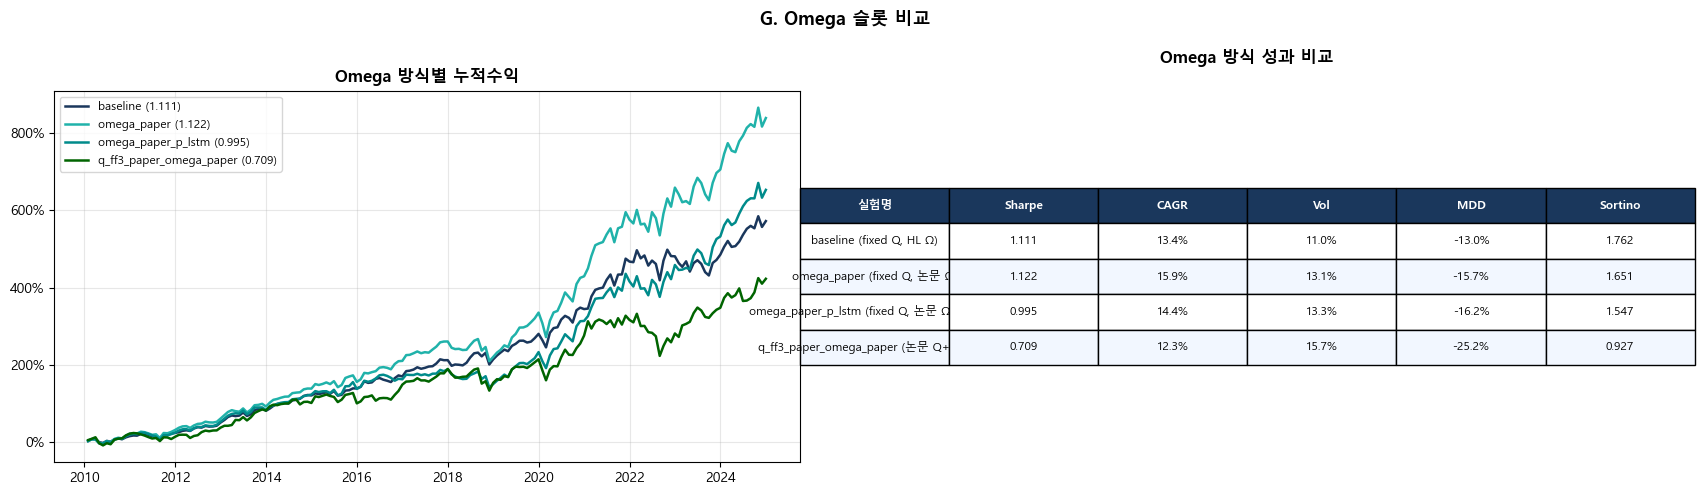

=== Omega 방식별 성과 요약 ===
실험명                                        Sharpe     CAGR      Vol      MDD
----------------------------------------------------------------------
baseline                                    1.111    13.4%    11.0%   -13.0%
omega_paper                                 1.122    15.9%    13.1%   -15.7%
omega_paper_p_lstm                          0.995    14.4%    13.3%   -16.2%
q_ff3_paper_omega_paper                     0.709    12.3%    15.7%   -25.2%

=== baseline 대비 Sharpe 변화 ===
  omega_paper                           : +0.011
  omega_paper_p_lstm                    : -0.116
  q_ff3_paper_omega_paper               : -0.403


In [53]:
# ── G1. Omega 방식별 성과 비교 ─────────────────────────────────
omega_exps   = ['baseline', 'omega_paper', 'omega_paper_p_lstm', 'q_ff3_paper', 'q_ff3_paper_omega_paper']
omega_labels = ['baseline\n(fixed Q, HL Ω)', 'omega_paper\n(fixed Q, 논문 Ω)', 'omega_paper_p_lstm\n(fixed Q, 논문 Ω, LSTM P)',
                'q_ff3_paper\n(논문 Q, HL Ω)', 'q_ff3_paper_omega_paper\n(논문 Q+Ω 완전)']
colors_om    = ['#1A375C', '#20B2AA', '#008B8B', '#228B22', '#006400']

# 존재하는 실험만
om_avail      = [(n, l, c) for n, l, c in zip(omega_exps, omega_labels, colors_om) if n in loaded]
omega_exps    = [x[0] for x in om_avail]
omega_labels  = [x[1] for x in om_avail]
colors_om     = [x[2] for x in om_avail]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# 누적수익
ax = axes[0]
for name, label, c in zip(omega_exps, omega_labels, colors_om):
    m = calc(name)
    ax.plot(m['cum'].index, m['cum'].values - 1,
            label=f"{label.split(chr(10))[0]} ({m['sharpe']:.3f})",
            linewidth=1.8, color=c)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Omega 방식별 누적수익', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)

# 성과 테이블
ax = axes[1]
ax.axis('off')
tdata = [['실험명', 'Sharpe', 'CAGR', 'Vol', 'MDD', 'Sortino']]
for name, label, c in zip(omega_exps, omega_labels, colors_om):
    m = calc(name)
    tdata.append([label.replace('\n', ' '),
                  f"{m['sharpe']:.3f}",
                  f"{m['cagr']*100:.1f}%",
                  f"{m['vol']*100:.1f}%",
                  f"{m['mdd']*100:.1f}%",
                  f"{m['sortino']:.3f}"])

tbl = ax.table(cellText=tdata[1:], colLabels=tdata[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.2, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1A375C'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F2F7FF')
ax.set_title('Omega 방식 성과 비교', fontweight='bold', pad=20)

plt.suptitle('G. Omega 슬롯 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'G_omega_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── G2. Omega 방식 요약 ─────────────────────────────────────────
print('=== Omega 방식별 성과 요약 ===')
print(f"{'실험명':40s}  {'Sharpe':>7s}  {'CAGR':>7s}  {'Vol':>7s}  {'MDD':>7s}")
print('-' * 70)
for name, label in zip(omega_exps, omega_labels):
    m = calc(name)
    tag = label.split('\n')[0]
    print(f"{tag:40s}  {m['sharpe']:>7.3f}  {m['cagr']*100:>6.1f}%  {m['vol']*100:>6.1f}%  {m['mdd']*100:>6.1f}%")

# baseline 대비 증감
print('\n=== baseline 대비 Sharpe 변화 ===')
base_sh = calc('baseline')['sharpe']
for name, label in zip(omega_exps[1:], omega_labels[1:]):
    tag = label.split('\n')[0]
    d = calc(name)['sharpe'] - base_sh
    print(f"  {tag:38s}: {d:+.3f}")